In [1]:
from pathlib import Path
import pandas as pd


# ============================================================
# 0. Settings
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")
eplus_path = pred_dir / "prediction_daily_EPlus_4P_FEBMAR.csv"

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 1. Group / label helpers
# ============================================================

label_map = {
    "_beta": r"LoD-1: $ihg^{1}_{1}$",
    "_gamma": r"LoD-2: $ihg^{2}_{1}$",
    "bY": r"LoD-3: $ihg^{3}_{1}$",
    "default_occ": "LoD-1: default occupancy",
    "ONSITE_occ": "LoD-2: on-site occupancy",
    "bldg_LoD_Y": "LoD-3: building LoD-Y occupancy",
}


def infer_eplus_group_from_text(text):
    text = str(text)

    if "4P__beta" in text or "_beta" in text:
        return "_beta"
    if "4P__gamma" in text or "_gamma" in text:
        return "_gamma"
    if "4P_bY" in text or "bY" in text:
        return "bY"

    return "unknown"


def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"

    return "RC"


def infer_rc_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"

    return "unknown"


# ============================================================
# 2. Load original E+ prediction_daily
# ============================================================

def load_original_eplus_prediction_daily(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ file: {path}")

    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    if "heating_energy" in df.columns and "sim_heating" not in df.columns:
        df = df.rename(columns={"heating_energy": "sim_heating"})

    if "Metering" in df.columns and "metered_heating" not in df.columns:
        df = df.rename(columns={"Metering": "metered_heating"})

    df["source"] = "EPlus"
    df["experiment_id"] = df.get("experiment_id", "EPlus_4P_FEBMAR")
    df["model_name"] = "EnergyPlus"

    df["scenario_group"] = df.apply(
        lambda row: infer_eplus_group_from_text(
            " ".join([
                str(row.get("scenario_group", "")),
                str(row.get("scenario_label", "")),
                str(row.get("sample_id", "")),
                str(row.get("experiment_id", "")),
            ])
        ),
        axis=1,
    )

    df["scenario_label"] = df["scenario_group"].map(label_map)

    keep_cols = [
        "source",
        "experiment_id",
        "model_name",
        "scenario_group",
        "scenario_label",
        "sample_id",
        "timestamp",
        "sim_heating",
        "metered_heating",
    ]

    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"E+ file is missing columns: {missing}")

    return df[keep_cols].copy()


# ============================================================
# 3. Load original six RC prediction_daily files
# ============================================================

def load_original_rc_prediction_daily(base_date, rc_run_ids, metered_by_date=None):
    dfs = []
    missing_files = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "baseline_prediction_daily.csv"
        )

        if not path.exists():
            missing_files.append(path)
            continue

        df = pd.read_csv(path)
        df["timestamp"] = pd.to_datetime(df["timestamp"])

        if "heating_energy" in df.columns and "sim_heating" not in df.columns:
            df = df.rename(columns={"heating_energy": "sim_heating"})

        if "sim_heating" not in df.columns:
            raise ValueError(
                f"{path} has no 'heating_energy' or 'sim_heating' column."
            )

        scenario_group = infer_rc_group(run_label)

        df["source"] = "RC"
        df["experiment_id"] = run_label
        df["model_name"] = infer_rc_model_name(run_label)
        df["scenario_group"] = scenario_group
        df["scenario_label"] = label_map.get(scenario_group, scenario_group)

        if "metered_heating" not in df.columns:
            if metered_by_date is not None:
                df = df.merge(
                    metered_by_date,
                    on="timestamp",
                    how="left",
                )
            else:
                df["metered_heating"] = pd.NA

        keep_cols = [
            "source",
            "experiment_id",
            "model_name",
            "scenario_group",
            "scenario_label",
            "sample_id",
            "timestamp",
            "sim_heating",
            "metered_heating",
        ]

        dfs.append(df[keep_cols].copy())

    if missing_files:
        print("[WARN] Missing RC files:")
        for path in missing_files:
            print("   ", path)

    if not dfs:
        raise ValueError("No RC prediction files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 4. Build prediction_daily from originals only
# ============================================================

prediction_daily_eplus = load_original_eplus_prediction_daily(eplus_path)

metered_by_date = (
    prediction_daily_eplus[["timestamp", "metered_heating"]]
    .dropna()
    .drop_duplicates(subset=["timestamp"])
    .copy()
)

prediction_daily_rc = load_original_rc_prediction_daily(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
    metered_by_date=metered_by_date,
)

prediction_daily = pd.concat(
    [
        prediction_daily_eplus,
        prediction_daily_rc,
    ],
    ignore_index=True,
)

prediction_daily = prediction_daily.sort_values(
    [
        "source",
        "model_name",
        "scenario_group",
        "sample_id",
        "timestamp",
    ]
).reset_index(drop=True)


# ============================================================
# 5. Check
# ============================================================

display(
    prediction_daily.groupby(
        ["source", "model_name", "scenario_group"]
    )["sample_id"].nunique()
)

display(prediction_daily.head())

source  model_name  scenario_group
EPlus   EnergyPlus  _beta             10
                    _gamma            10
                    bY                10
                    unknown           20
RC      3R2C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
        5R1C        ONSITE_occ        10
                    bldg_LoD_Y        10
                    default_occ       10
Name: sample_id, dtype: int64

,source,experiment_id,model_name,scenario_group,scenario_label,sample_id,timestamp,sim_heating,metered_heating
0,EPlus,EPlus_4P_FEBMAR,EnergyPlus,_beta,LoD-1: $ihg^{1}_{1}$,posterior__4P__beta_Z2_S2_FEBMAR__4P__beta_Z2_...,2023-01-20,0.476889,0.349152
1,EPlus,EPlus_4P_FEBMAR,EnergyPlus,_beta,LoD-1: $ihg^{1}_{1}$,posterior__4P__beta_Z2_S2_FEBMAR__4P__beta_Z2_...,2023-01-21,0.319120,0.349152
2,EPlus,EPlus_4P_FEBMAR,EnergyPlus,_beta,LoD-1: $ihg^{1}_{1}$,posterior__4P__beta_Z2_S2_FEBMAR__4P__beta_Z2_...,2023-01-22,0.312856,0.349152
3,EPlus,EPlus_4P_FEBMAR,EnergyPlus,_beta,LoD-1: $ihg^{1}_{1}$,posterior__4P__beta_Z2_S2_FEBMAR__4P__beta_Z2_...,2023-01-23,0.385320,0.351903
4,EPlus,EPlus_4P_FEBMAR,EnergyPlus,_beta,LoD-1: $ihg^{1}_{1}$,posterior__4P__beta_Z2_S2_FEBMAR__4P__beta_Z2_...,2023-01-24,0.347645,0.310323


In [2]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'Arial',"mathtext.fontset": "stix",
    'font.size': 14,
    'axes.labelsize': 18,
    'legend.fontsize': 12,
})

# ============================================================
# 1. Paths
# ============================================================

BASE_DATE = "JUN11"

pred_dir = Path(f"_json/_run/{BASE_DATE}/_prediction_daily")

eplus_ecm_path = (
    pred_dir / "ecm_savings_daily_EPlus_4P_FEBMAR_LoD1to3.csv"
)

rc_run_ids = [
    "ETHlib_default_occ",
    "ETHlib_ONSITE_occ",
    "ETHlib_bldg_LoD_Y",
    "ETHlib_3R2C_default_occ",
    "ETHlib_3R2C_ONSITE_occ",
    "ETHlib_3R2C_bldg_LoD_Y",
]


# ============================================================
# 2. Harmonisation maps
# ============================================================

quality_map = {
    # E+
    "beta": "LoD-1",
    "gamma": "LoD-2",
    "yearly": "LoD-3",
    "_beta": "LoD-1",
    "_gamma": "LoD-2",
    "bY": "LoD-3",

    # RC
    "default_occ": "LoD-1",
    "ONSITE_occ": "LoD-2",
    "bldg_LoD_Y": "LoD-3",
}

quality_label_map = {
    "LoD-1": r"LoD-1",
    "LoD-2": r"LoD-2",
    "LoD-3": r"LoD-3",
}

eplus_ecm_to_common = {
    "O&M-1": "O&M-1",
    "O&M-2": "O&M-2",
    "O&M-3": "O&M-3",
    "O&M-5": "O&M-4",

    # Keep these, but they may not have direct RC equivalents.
    "O&M-4": "E+ only: O&M-4",
    "O&M-6": "E+ only: O&M-6",
}

# RC exported ECM names -> common names
rc_ecm_to_common = {
    "ECM-1_setpoint_19C": "O&M-1",
    "ECM-3_setpoint_19C_reschedule_8_8_8": "O&M-2",
    "ECM-2_reschedule_8_8_8": "O&M-3",

    # This matches your note that E+ O&M-5 corresponds to RC O&M-4.
    "ECM-4_setpoint_19C_default_infiltration": "O&M-4",

    # Keep this separately because it is not clearly one of the four common ECMs.
    "ECM-5_reschedule_8_8_8_default_infiltration": "RC only: setpoint + default infiltration",
}

ecm_label_map = {
    "O&M-1": "ECM-1:\nHeating setpoint change",
    "O&M-2": "ECM-2:\nHeating setpoint change & scheduling",
    "O&M-3": "ECM-3:\nHeating scheduling",
    "O&M-4": "ECM-4:\nHeating setpoint change\n+ Reduced window opening",
    "E+ only: O&M-4": "E+ only:\nO&M-4",
    "E+ only: O&M-6": "E+ only:\nO&M-6",
    "RC only: setpoint + default infiltration": "RC only:\Setpoint change\n+ Reduced window opening",
}

common_ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]


# ============================================================
# 3. Load E+ ECM savings
# ============================================================

def load_eplus_ecm_savings(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Missing E+ ECM savings file: {path}")

    df = pd.read_csv(path)

    if "scenario" not in df.columns:
        raise ValueError("E+ file needs a 'scenario' column.")

    if "ecm" not in df.columns:
        raise ValueError("E+ file needs an 'ecm' column.")

    df["source"] = "EPlus"
    df["engine"] = "EnergyPlus"
    df["model_name"] = "EnergyPlus"

    df["data_quality"] = df["scenario"].map(quality_map)

    if "scenario_group" in df.columns:
        df["data_quality"] = df["data_quality"].fillna(
            df["scenario_group"].map(quality_map)
        )

    df["ecm_common"] = df["ecm"].map(eplus_ecm_to_common).fillna(df["ecm"])
    df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

    return df


# ============================================================
# 4. Load RC ECM savings
# ============================================================

def infer_rc_model_name(run_label):
    if "ETHlib_3R2C" in run_label:
        return "3R2C"
    if "ETHlib" in run_label:
        return "5R1C"
    return "RC"


def infer_rc_scenario_group(run_label):
    if "default_occ" in run_label:
        return "default_occ"
    if "ONSITE_occ" in run_label:
        return "ONSITE_occ"
    if "bldg_LoD_Y" in run_label:
        return "bldg_LoD_Y"
    return "unknown"


def load_rc_ecm_savings(base_date, rc_run_ids):
    dfs = []
    missing = []

    for run_id in rc_run_ids:
        run_label = f"{base_date}__{run_id}"

        path = (
            Path(f"_json/_run/{run_label}")
            / "_outcome"
            / run_label
            / "ecm_savings_daily.csv"
        )

        if not path.exists():
            missing.append(path)
            continue

        df = pd.read_csv(path)

        scenario_group = infer_rc_scenario_group(run_label)
        model_name = infer_rc_model_name(run_label)

        df["source"] = "RC"
        df["engine"] = model_name
        df["model_name"] = model_name
        df["experiment_id"] = run_label
        df["scenario"] = scenario_group
        df["scenario_group"] = scenario_group
        df["data_quality"] = quality_map.get(scenario_group, "unknown")

        if "ecm" not in df.columns:
            raise ValueError(f"RC file has no 'ecm' column: {path}")

        df["ecm_common"] = df["ecm"].map(rc_ecm_to_common).fillna(df["ecm"])
        df["ecm_label"] = df["ecm_common"].map(ecm_label_map).fillna(df["ecm_common"])

        if "saving_frac" not in df.columns and "saving_rel" in df.columns:
            df["saving_frac"] = df["saving_rel"] / 100.0

        dfs.append(df)

    if missing:
        print("[WARN] Missing RC ECM files:")
        for p in missing:
            print("   ", p)

    if not dfs:
        raise ValueError("No RC ECM savings files were loaded.")

    return pd.concat(dfs, ignore_index=True)


# ============================================================
# 5. Combine and save
# ============================================================

ecm_eplus = load_eplus_ecm_savings(eplus_ecm_path)

ecm_rc = load_rc_ecm_savings(
    base_date=BASE_DATE,
    rc_run_ids=rc_run_ids,
)

ecm_savings_all = pd.concat(
    [ecm_eplus, ecm_rc],
    ignore_index=True,
)

# Keep only common comparable ECMs and LoD-1 to LoD-3
ecm_savings_common = ecm_savings_all[
    ecm_savings_all["ecm_common"].isin(common_ecm_order)
    & ecm_savings_all["data_quality"].isin(["LoD-1", "LoD-2", "LoD-3"])
].copy()

ecm_savings_common["ecm_label"] = pd.Categorical(
    ecm_savings_common["ecm_label"],
    categories=[ecm_label_map[x] for x in common_ecm_order],
    ordered=True,
)

ecm_savings_common["data_quality"] = pd.Categorical(
    ecm_savings_common["data_quality"],
    categories=["LoD-1", "LoD-2", "LoD-3"],
    ordered=True,
)

ecm_savings_common["engine"] = pd.Categorical(
    ecm_savings_common["engine"],
    categories=["EnergyPlus", "5R1C", "3R2C"],
    ordered=True,
)

display(
    ecm_savings_common.groupby(
        ["engine", "data_quality", "ecm_common"]
    )["sample_id"].nunique()
)

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42471/2771701236.py:247: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ecm_savings_common.groupby(


engine      data_quality  ecm_common
EnergyPlus  LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
5R1C        LoD-1         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-2         O&M-1         10
                          O&M-2         10
                          O&M-3         10
                          O&M-4         10
            LoD-3         O&M-1         10
                          O&M-2         10
                 

# RQ2

In [3]:
import re
import numpy as np
import pandas as pd
from scipy.stats import pearsonr


# ============================================================
# 1. Helper functions
# ============================================================

def canonical_sample_key(x):
    """
    Converts sample IDs into a common merge key.

    Examples
    --------
    sample_001 -> 1
    sample_010 -> 10
    0          -> 0
    1          -> 1
    """
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)

    m = re.search(r"(\d+)$", s)
    if m:
        return str(int(m.group(1)))

    return s


def add_engine_quality_keys(prediction_daily):
    df = prediction_daily.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    def engine_key(row):
        model = str(row.get("model_name", ""))
        source = str(row.get("source", ""))

        if source == "EPlus" or model == "EnergyPlus":
            return "EnergyPlus"
        if model == "5R1C":
            return "5R1C"
        if model == "3R2C":
            return "3R2C"

        return model

    df["engine"] = df.apply(engine_key, axis=1)

    quality_map = {
        "_beta": "LoD-1",
        "_gamma": "LoD-2",
        "bY": "LoD-3",
        "default_occ": "LoD-1",
        "ONSITE_occ": "LoD-2",
        "bldg_LoD_Y": "LoD-3",
    }

    df["data_quality"] = df["scenario_group"].map(quality_map)

    df = df[df["data_quality"].notna()].copy()

    return df


def ensure_sim_heating_column(prediction_daily):
    """
    Creates a unified sim_heating_rq2 column.

    If sim_heating already exists, it is used.
    If EnergyPlus heating is stored under another compatible kWh column,
    add that column name to candidate_cols.
    """
    df = prediction_daily.copy()

    candidate_cols = [
        "sim_heating",
        "sim_heating_kwh",
        "heating_kwh",
        "district_heating_kwh",
        "DistrictHeatingWater_Facility_kWh",
    ]

    df["sim_heating_rq2"] = np.nan

    for col in candidate_cols:
        if col in df.columns:
            df["sim_heating_rq2"] = df["sim_heating_rq2"].where(
                df["sim_heating_rq2"].notna(),
                df[col],
            )

    return df


# ============================================================
# 2. Build RQ2 dataframe
# ============================================================

def make_rq2_df_minimal(
    prediction_daily,
    ecm_savings_common,
    start="2023-01-20",
    end="2023-03-17",
    engine_order=("5R1C", "3R2C", "EnergyPlus"),
    quality_order=("LoD-1", "LoD-2", "LoD-3"),
    ecm_order=("O&M-1", "O&M-2", "O&M-3", "O&M-4"),
):
    pred = ensure_sim_heating_column(prediction_daily)
    pred = add_engine_quality_keys(pred)

    pred["sample_key"] = pred["sample_id"].map(canonical_sample_key)

    pred = pred[
        (pred["timestamp"] >= pd.to_datetime(start))
        & (pred["timestamp"] <= pd.to_datetime(end))
        & (pred["engine"].isin(engine_order))
        & (pred["data_quality"].isin(quality_order))
    ].copy()

    if pred.empty:
        raise ValueError("No prediction rows remain after filtering.")

    # --------------------------------------------------------
    # Check whether EnergyPlus has usable simulated heating
    # --------------------------------------------------------

    sim_check = (
        pred.groupby(["engine", "data_quality"], observed=True)
        .agg(
            n_rows=("sample_key", "size"),
            n_samples=("sample_key", "nunique"),
            non_null_sim=("sim_heating_rq2", lambda x: x.notna().sum()),
            non_null_metered=("metered_heating", lambda x: x.notna().sum()),
            first_date=("timestamp", "min"),
            last_date=("timestamp", "max"),
        )
        .reset_index()
    )

    display(sim_check)

    # --------------------------------------------------------
    # Simulated daily heating per sample
    # --------------------------------------------------------

    sim_daily = (
        pred.groupby(
            ["engine", "data_quality", "sample_key", "timestamp"],
            as_index=False,
            observed=True,
        )
        .agg(
            sim_heating=("sim_heating_rq2", lambda x: x.sum(min_count=1))
        )
    )

    # --------------------------------------------------------
    # Metered daily heating
    # --------------------------------------------------------

    metered_daily = (
        pred.dropna(subset=["metered_heating"])
        .groupby("timestamp", as_index=False)
        .agg(metered_heating=("metered_heating", "first"))
    )

    if metered_daily.empty:
        raise ValueError("No metered_heating values found in prediction_daily.")

    pred_eval = sim_daily.merge(
        metered_daily,
        on="timestamp",
        how="left",
    )

    # --------------------------------------------------------
    # Prediction error metrics per sample
    # --------------------------------------------------------

    metric_rows = []

    for keys, d in pred_eval.groupby(
        ["engine", "data_quality", "sample_key"],
        observed=True,
    ):
        engine, data_quality, sample_key = keys

        d = d.dropna(subset=["sim_heating", "metered_heating"]).copy()

        if len(d) < 2:
            cvrmse = np.nan
            nmbe = np.nan
        else:
            obs = d["metered_heating"]
            sim = d["sim_heating"]

            obs_mean = obs.mean()
            error = obs - sim

            if obs_mean == 0 or pd.isna(obs_mean):
                cvrmse = np.nan
                nmbe = np.nan
            else:
                rmse = np.sqrt(np.mean(error ** 2))
                cvrmse = rmse / obs_mean * 100
                nmbe = error.sum() / (len(d) * obs_mean) * 100

        if pd.notna(cvrmse) and pd.notna(nmbe):
            gof = np.sqrt(cvrmse ** 2 + nmbe ** 2) / np.sqrt(2)
        else:
            gof = np.nan

        metric_rows.append(
            {
                "engine": engine,
                "data_quality": data_quality,
                "sample_key": sample_key,
                "n_days": len(d),
                "CVRMSE": cvrmse,
                "NMBE": nmbe,
                "GOF": gof,
            }
        )

    metric_min = pd.DataFrame(metric_rows)

    # --------------------------------------------------------
    # ECM saving estimates
    # --------------------------------------------------------

    ecm = ecm_savings_common.copy()
    ecm["sample_key"] = ecm["sample_id"].map(canonical_sample_key)

    ecm = ecm[
        ecm["engine"].isin(engine_order)
        & ecm["data_quality"].isin(quality_order)
        & ecm["ecm_common"].isin(ecm_order)
    ][
        [
            "engine",
            "data_quality",
            "sample_key",
            "ecm_common",
            "saving_abs",
            "saving_rel",
        ]
    ].copy()

    # --------------------------------------------------------
    # Merge check before inner merge
    # --------------------------------------------------------

    metric_keys = metric_min[
        ["engine", "data_quality", "sample_key"]
    ].drop_duplicates()

    ecm_keys = ecm[
        ["engine", "data_quality", "sample_key"]
    ].drop_duplicates()

    merge_check = (
        ecm_keys.merge(
            metric_keys,
            on=["engine", "data_quality", "sample_key"],
            how="outer",
            indicator=True,
        )
        .groupby(["engine", "data_quality", "_merge"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )

    display(merge_check)

    # --------------------------------------------------------
    # Final RQ2 dataframe
    # --------------------------------------------------------

    rq2_df = ecm.merge(
        metric_min,
        on=["engine", "data_quality", "sample_key"],
        how="inner",
    )

    final_check = (
        rq2_df.groupby(["engine", "data_quality", "ecm_common"], observed=True)
        .agg(
            n=("sample_key", "nunique"),
            missing_CVRMSE=("CVRMSE", lambda x: x.isna().sum()),
            missing_NMBE=("NMBE", lambda x: x.isna().sum()),
            missing_GOF=("GOF", lambda x: x.isna().sum()),
        )
        .reset_index()
    )

    display(final_check)

    return rq2_df, metric_min, merge_check


# ============================================================
# 3. Pearson's r
# ============================================================

def compute_rq2_pearson(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
    min_n=3,
):
    rows = []

    for keys, d in rq2_df.groupby(
        ["ecm_common", "engine", "data_quality"],
        observed=True,
    ):
        ecm_common, engine, data_quality = keys

        d = d.dropna(subset=[error_metric, saving_metric]).copy()

        if len(d) < min_n:
            r = np.nan
            p = np.nan
        elif d[error_metric].nunique() < 2:
            r = np.nan
            p = np.nan
        elif d[saving_metric].nunique() < 2:
            r = np.nan
            p = np.nan
        else:
            r, p = pearsonr(d[error_metric], d[saving_metric])

        rows.append(
            {
                "ecm_common": ecm_common,
                "engine": engine,
                "data_quality": data_quality,
                "n": len(d),
                "error_metric": error_metric,
                "saving_metric": saving_metric,
                "pearson_r": r,
                "p_value": p,
            }
        )

    return pd.DataFrame(rows)


# ============================================================
# 4. Run
# ============================================================

rq2_df, metric_min, merge_check = make_rq2_df_minimal(
    prediction_daily,
    ecm_savings_common,
    start="2023-01-20",
    end="2023-03-17",
)

pearson_abs = compute_rq2_pearson(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
)

pearson_rel = compute_rq2_pearson(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_rel",
)

display(rq2_df.head())
display(metric_min.head())
display(pearson_abs)
display(pearson_rel)

,engine,data_quality,n_rows,n_samples,non_null_sim,non_null_metered,first_date,last_date
0,3R2C,LoD-1,570,10,570,570,2023-01-20,2023-03-17
1,3R2C,LoD-2,570,10,570,570,2023-01-20,2023-03-17
2,3R2C,LoD-3,570,10,570,570,2023-01-20,2023-03-17
3,5R1C,LoD-1,570,10,570,570,2023-01-20,2023-03-17
4,5R1C,LoD-2,570,10,570,570,2023-01-20,2023-03-17
5,5R1C,LoD-3,570,10,570,570,2023-01-20,2023-03-17
6,EnergyPlus,LoD-1,570,10,570,570,2023-01-20,2023-03-17
7,EnergyPlus,LoD-2,570,10,570,570,2023-01-20,2023-03-17
8,EnergyPlus,LoD-3,570,10,570,570,2023-01-20,2023-03-17


_merge,engine,data_quality,left_only,right_only,both
0,3R2C,LoD-1,0,0,10
1,3R2C,LoD-2,0,0,10
2,3R2C,LoD-3,0,0,10
3,5R1C,LoD-1,0,0,10
4,5R1C,LoD-2,0,0,10
5,5R1C,LoD-3,0,0,10
6,EnergyPlus,LoD-1,1,1,9
7,EnergyPlus,LoD-2,1,1,9
8,EnergyPlus,LoD-3,1,1,9


,engine,data_quality,ecm_common,n,missing_CVRMSE,missing_NMBE,missing_GOF
0,3R2C,LoD-1,O&M-1,10,0,0,0
1,3R2C,LoD-1,O&M-2,10,0,0,0
2,3R2C,LoD-1,O&M-3,10,0,0,0
3,3R2C,LoD-1,O&M-4,10,0,0,0
4,3R2C,LoD-2,O&M-1,10,0,0,0
5,3R2C,LoD-2,O&M-2,10,0,0,0
6,3R2C,LoD-2,O&M-3,10,0,0,0
7,3R2C,LoD-2,O&M-4,10,0,0,0
8,3R2C,LoD-3,O&M-1,10,0,0,0
9,3R2C,LoD-3,O&M-2,10,0,0,0


,engine,data_quality,sample_key,ecm_common,saving_abs,saving_rel,n_days,CVRMSE,NMBE,GOF
0,EnergyPlus,LoD-1,1,O&M-1,2.238073,11.389545,57,31.648153,-22.415177,27.423035
1,EnergyPlus,LoD-1,2,O&M-1,2.396093,11.985274,57,30.124696,-22.431363,26.558081
2,EnergyPlus,LoD-1,3,O&M-1,1.851728,9.261130,57,25.078055,-13.324988,20.080639
3,EnergyPlus,LoD-1,4,O&M-1,1.849751,9.994637,57,33.664783,-26.653155,30.362051
4,EnergyPlus,LoD-1,5,O&M-1,1.950161,9.428311,57,28.369135,-17.167630,23.447125


,engine,data_quality,sample_key,n_days,CVRMSE,NMBE,GOF
0,3R2C,LoD-1,0,57,44.398660,4.684041,31.568824
1,3R2C,LoD-1,1,57,44.414296,-5.448538,31.641083
2,3R2C,LoD-1,2,57,44.683765,-4.618287,31.764504
3,3R2C,LoD-1,3,57,44.782654,6.494432,31.997373
4,3R2C,LoD-1,4,57,44.412003,-0.253218,31.404539


,ecm_common,engine,data_quality,n,error_metric,saving_metric,pearson_r,p_value
0,O&M-1,3R2C,LoD-1,10,GOF,saving_abs,0.198699,0.582104
1,O&M-1,3R2C,LoD-2,10,GOF,saving_abs,0.936506,0.000066
2,O&M-1,3R2C,LoD-3,10,GOF,saving_abs,0.710977,0.021163
3,O&M-1,5R1C,LoD-1,10,GOF,saving_abs,0.744290,0.013555
4,O&M-1,5R1C,LoD-2,10,GOF,saving_abs,0.912990,0.000226
5,O&M-1,5R1C,LoD-3,10,GOF,saving_abs,0.672716,0.033045
6,O&M-1,EnergyPlus,LoD-1,9,GOF,saving_abs,-0.020776,0.957690
7,O&M-1,EnergyPlus,LoD-2,9,GOF,saving_abs,-0.358819,0.342976
8,O&M-1,EnergyPlus,LoD-3,9,GOF,saving_abs,0.025162,0.948768
9,O&M-2,3R2C,LoD-1,10,GOF,saving_abs,0.218167,0.544833


,ecm_common,engine,data_quality,n,error_metric,saving_metric,pearson_r,p_value
0,O&M-1,3R2C,LoD-1,10,GOF,saving_rel,-0.090558,0.803520
1,O&M-1,3R2C,LoD-2,10,GOF,saving_rel,0.323395,0.362032
2,O&M-1,3R2C,LoD-3,10,GOF,saving_rel,0.213913,0.552895
3,O&M-1,5R1C,LoD-1,10,GOF,saving_rel,-0.613773,0.059093
4,O&M-1,5R1C,LoD-2,10,GOF,saving_rel,-0.599533,0.066956
5,O&M-1,5R1C,LoD-3,10,GOF,saving_rel,0.614071,0.058935
6,O&M-1,EnergyPlus,LoD-1,9,GOF,saving_rel,-0.067783,0.862441
7,O&M-1,EnergyPlus,LoD-2,9,GOF,saving_rel,-0.402280,0.283110
8,O&M-1,EnergyPlus,LoD-3,9,GOF,saving_rel,0.103311,0.791400
9,O&M-2,3R2C,LoD-1,10,GOF,saving_rel,-0.157418,0.664056


In [4]:
def run_rq2_pearson_minimal(
    rq2_df,
    error_metrics=("CVRMSE", "NMBE",  "GOF"),
    saving_metrics=("saving_abs", "saving_rel"),
):
    rows = []

    for ecm, d_ecm in rq2_df.groupby("ecm_common", observed=True):
        for error_metric in error_metrics:
            for saving_metric in saving_metrics:
                d = d_ecm[[error_metric, saving_metric]].dropna()

                if len(d) < 3:
                    r = np.nan
                    p = np.nan
                elif d[error_metric].nunique() < 2 or d[saving_metric].nunique() < 2:
                    r = np.nan
                    p = np.nan
                else:
                    r, p = pearsonr(d[error_metric], d[saving_metric])

                rows.append({
                    "ECM": ecm,
                    "Error metric": error_metric,
                    "Saving metric": saving_metric,
                    "n": len(d),
                    "Pearson r": r,
                    "p_value": p,
                    "Significant": p < 0.05 if pd.notna(p) else False,
                })

    return pd.DataFrame(rows)


rq2_pearson = run_rq2_pearson_minimal(rq2_df)

rq2_pearson_display = rq2_pearson.copy()

rq2_pearson_display["Pearson r"] = rq2_pearson_display["Pearson r"].round(3)

rq2_pearson_display["p_value"] = rq2_pearson_display["p_value"].apply(
    lambda p: "< 0.001" if pd.notna(p) and p < 0.001 else f"{p:.3f}"
)

display(rq2_pearson_display)

,ECM,Error metric,Saving metric,n,Pearson r,p_value,Significant
0,O&M-1,CVRMSE,saving_abs,87,0.785,< 0.001,True
1,O&M-1,CVRMSE,saving_rel,87,0.768,< 0.001,True
2,O&M-1,NMBE,saving_abs,87,0.291,0.006,True
3,O&M-1,NMBE,saving_rel,87,0.470,< 0.001,True
4,O&M-1,GOF,saving_abs,87,0.563,< 0.001,True
5,O&M-1,GOF,saving_rel,87,0.504,< 0.001,True
6,O&M-2,CVRMSE,saving_abs,87,0.695,< 0.001,True
7,O&M-2,CVRMSE,saving_rel,87,0.667,< 0.001,True
8,O&M-2,NMBE,saving_abs,87,0.363,< 0.001,True
9,O&M-2,NMBE,saving_rel,87,0.534,< 0.001,True


In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib.lines import Line2D

def fmt_p(p):
    if pd.isna(p):
        return "p = NA"
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"



In [33]:
def plot_rq2_scatter_simple(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
):
    engine_order = ["5R1C", "3R2C", "EnergyPlus"]
    quality_order = ["LoD-1", "LoD-2", "LoD-3"]
    ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

    metric_label_map = {
        "GOF": "GOF",
        "CVRMSE": "CVRMSE (%)",
        "NMBE": "NMBE (%)",
        "saving_abs": (
            r"Absolute savings "
            r"($\mathrm{kWh\,m^{-2}}$)"
        ),
        "saving_frac": "Relative savings (%)",
        "saving_pct": "Relative savings (%)",
    }

    x_label = metric_label_map.get(error_metric, error_metric)
    y_label = metric_label_map.get(saving_metric, saving_metric)

    quality_display_map = {
        "LoD-1": r"$\mathregular{LoD}_{\mathregular{d}}$=1",
        "LoD-2": r"$\mathregular{LoD}_{\mathregular{d}}$=2",
        "LoD-3": r"$\mathregular{LoD}_{\mathregular{d}}$=3",
    }

    ecm_label_map = {
        "O&M-1": "ECM-1:\nHeating setpoint change",
        "O&M-2": "ECM-2:\nHeating setpoint change & scheduling",
        "O&M-3": "ECM-3:\nHeating scheduling",
        "O&M-4": "ECM-4:\nHeating setpoint change\n+ reduced window opening",
    }

    engine_palette = {
        "EnergyPlus": "red",
        "5R1C": "blue",
        "3R2C": "green",
    }

    marker_map = {
        "LoD-1": "o",
        "LoD-2": "s",
        "LoD-3": "^",
    }

    df = rq2_df.copy()
    df = df[
        df["engine"].isin(engine_order)
        & df["data_quality"].isin(quality_order)
        & df["ecm_common"].isin(ecm_order)
    ].copy()

    fig, axes = plt.subplots(
        1,
        len(ecm_order),
        figsize=(21, 6),
        sharey=True,
        constrained_layout=True,
    )

    for i, (ax, ecm) in enumerate(zip(axes, ecm_order)):
        d = df[df["ecm_common"] == ecm].dropna(
            subset=[error_metric, saving_metric]
        )

        sns.regplot(
            data=d,
            x=error_metric,
            y=saving_metric,
            scatter=False,
            color="grey",
            line_kws={
                "linestyle": "--",
                "linewidth": 1.3,
                "alpha": 0.8,
            },
            ax=ax,
        )

        sns.scatterplot(
            data=d,
            x=error_metric,
            y=saving_metric,
            hue="engine",
            hue_order=engine_order,
            palette=engine_palette,
            style="data_quality",
            style_order=quality_order,
            markers=marker_map,
            s=55,
            alpha=0.85,
            edgecolor="grey",
            linewidth=0.4,
            ax=ax,
            legend=False,
        )

        ax.set_title(ecm_label_map.get(ecm, ecm))
        ax.set_xlabel(x_label)

        if i == 0:
            ax.set_ylabel(y_label)
        else:
            ax.set_ylabel("")

        ax.grid(True, alpha=0.3)

        if (
            len(d) >= 3
            and d[error_metric].nunique() > 1
            and d[saving_metric].nunique() > 1
        ):
            r, p = pearsonr(d[error_metric], d[saving_metric])
            stat_text = f"r = {r:.3f}\n{fmt_p(p)}"
        else:
            stat_text = "r = NA\np = NA"

        ax.text(
            0.04,
            0.96,
            stat_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "grey",
                "alpha": 0.85,
            },
        )

        ax.set_title(ecm_label_map.get(ecm, ecm))
        

        ax.set_xlabel(x_label)

        ax.grid(True, alpha=0.3)
    fig.supxlabel(x_label) 
    axes[0].set_ylabel(y_label)

    legend_handles = []
    legend_labels = []

    for engine in engine_order:
        for lod in quality_order:
            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker=marker_map[lod],
                    color="w",
                    markerfacecolor=engine_palette[engine],
                    markeredgecolor="grey",
                    markersize=7,
                    linewidth=0,
                )
            )
            legend_labels.append(
                f"{engine} | {quality_display_map[lod]}"
            )

    axes[-1].legend(
        legend_handles,
        legend_labels,
        title="",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
    )

    plt.tight_layout()
    plt.show()

    return fig, axes

/var/folders/7p/_yzdn45s5c7_bd88lqmn1cw80000gn/T/ipykernel_42471/1970732986.py:177: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


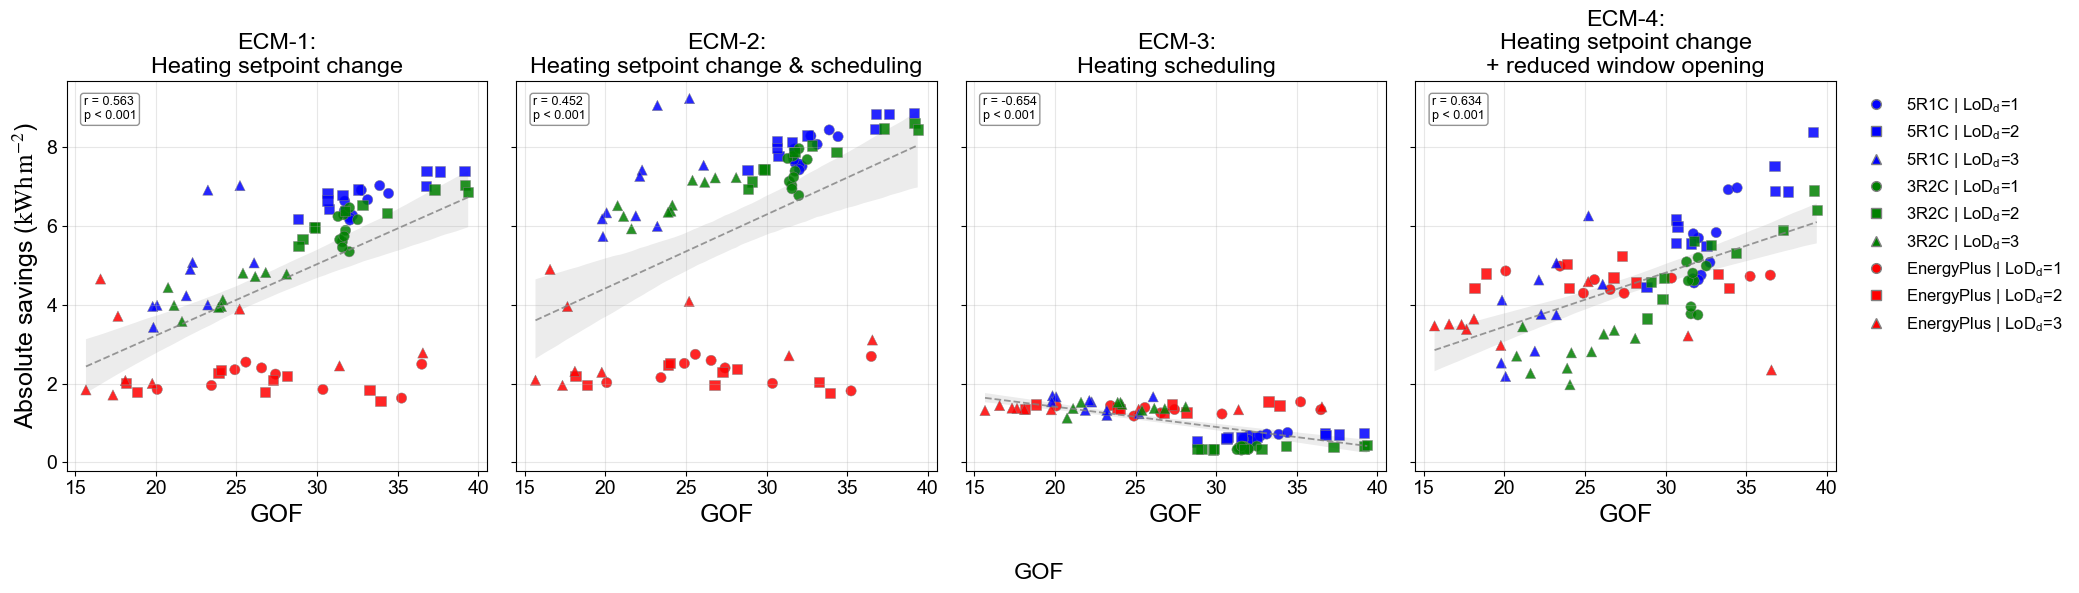

(<Figure size 2100x600 with 4 Axes>,
 array([<Axes: title={'center': 'ECM-1:\nHeating setpoint change'}, xlabel='GOF', ylabel='Absolute savings ($\\mathrm{kWh\\,m^{-2}}$)'>,
        <Axes: title={'center': 'ECM-2:\nHeating setpoint change & scheduling'}, xlabel='GOF'>,
        <Axes: title={'center': 'ECM-3:\nHeating scheduling'}, xlabel='GOF'>,
        <Axes: title={'center': 'ECM-4:\nHeating setpoint change\n+ reduced window opening'}, xlabel='GOF'>],
       dtype=object))

In [34]:
plot_rq2_scatter_simple(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
)

In [106]:
def plot_rq2_scatter_by_lod_ci(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
):
    engine_order = ["5R1C", "3R2C","EnergyPlus", ]
    quality_order = ["LoD-1", "LoD-2", "LoD-3"]
    ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

    metric_label_map = {
        "GOF": "GOF",
        "CVRMSE": "CVRMSE (%)",
        "NMBE": "NMBE (%)",
        "saving_abs": (
            r"Absolute savings "
            r"($\mathrm{kWh\,m^{-2}}$)"
        ),
        "saving_frac": "Relative savings (%)",
        "saving_pct": "Relative savings (%)",
    }

    x_label = metric_label_map.get(error_metric, error_metric)
    y_label = metric_label_map.get(saving_metric, saving_metric)

    quality_display_map = {
        "LoD-1": r"$\mathregular{LoD}_{\mathregular{d}}$=1",
        "LoD-2": r"$\mathregular{LoD}_{\mathregular{d}}$=2",
        "LoD-3": r"$\mathregular{LoD}_{\mathregular{d}}$=3",
    }

    quality_text_map = {
        "LoD-1": r"$\mathregular{LoD}_{\mathregular{d}}$=1",
        "LoD-2": r"$\mathregular{LoD}_{\mathregular{d}}$=2",
        "LoD-3": r"$\mathregular{LoD}_{\mathregular{d}}$=3",
    }

    ecm_label_map = {
        "O&M-1": "ECM-1:\nHeating setpoint change",
        "O&M-2": "ECM-2:\nHeating setpoint change & scheduling",
        "O&M-3": "ECM-3:\nHeating scheduling",
        "O&M-4": (
            "ECM-4:\nHeating setpoint change\n"
            "+ reduced window opening"
        ),
    }

    # Colour = LoD
    lod_colour_map = {
        "LoD-1": "#F4A261",  # orange
        "LoD-2": "#2EC4B6",  # turquoise
        "LoD-3": "#E78AC3",  # pink
    }

    # Symbol = engine
    engine_marker_map = {
        "EnergyPlus": "+",
        "5R1C": "*",
        "3R2C": "p",
    }

    line_style_map = {
        "LoD-1": "-",
        "LoD-2": "--",
        "LoD-3": ":",
    }

    df = rq2_df.copy()
    df = df[
        df["engine"].isin(engine_order)
        & df["data_quality"].isin(quality_order)
        & df["ecm_common"].isin(ecm_order)
    ].copy()

    fig, axes = plt.subplots(
        1,
        len(ecm_order),
        figsize=(21, 6),
        sharey=True,
        constrained_layout=True,
    )

    for i, (ax, ecm) in enumerate(zip(axes, ecm_order)):
        d = df[df["ecm_common"] == ecm].dropna(
            subset=[error_metric, saving_metric]
        )

        stat_lines = []

        # LoD-specific regression lines and confidence bands
        for lod in quality_order:
            d_lod = d[d["data_quality"] == lod].copy()

            if (
                len(d_lod) >= 3
                and d_lod[error_metric].nunique() > 1
                and d_lod[saving_metric].nunique() > 1
            ):
                sns.regplot(
                    data=d_lod,
                    x=error_metric,
                    y=saving_metric,
                    scatter=False,
                    ci=95,
                    color=lod_colour_map[lod],
                    line_kws={
                        "linestyle": line_style_map[lod],
                        "linewidth": 1.6,
                        "alpha": 0.95,
                    },
                    ax=ax,
                )

                r, p = pearsonr(
                    d_lod[error_metric],
                    d_lod[saving_metric],
                )

                stat_lines.append(
                    f"{quality_text_map[lod]}: r = {r:.3f}, {fmt_p(p)}"
                )
            else:
                stat_lines.append(
                    f"{quality_text_map[lod]}: r = NA, p = NA"
                )

        # Manual scatter avoids seaborn marker-mixing error
        for lod in quality_order:
            for engine in engine_order:
                d_point = d[
                    (d["data_quality"] == lod)
                    & (d["engine"] == engine)
                ]

                if d_point.empty:
                    continue

                ax.scatter(
                    d_point[error_metric],
                    d_point[saving_metric],
                    marker=engine_marker_map[engine],
                    color=lod_colour_map[lod],
                    s=95,
                    alpha=0.75,
                    linewidths=1.4,
                    zorder=4,
                )

        ax.text(
            0.04,
            0.96,
            "\n".join(stat_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "grey",
                "alpha": 0.85,
            },
        )

        ax.set_title(ecm_label_map.get(ecm, ecm))
        ax.set_xlabel("")

        if i == 0:
            ax.set_ylabel(y_label)
        else:
            ax.set_ylabel("")

        ax.grid(True, alpha=0.3)

    fig.supxlabel(x_label)

    # One merged legend: data quality + model form
    legend_handles = []
    legend_labels = []

    # Data quality: coloured markers
    for lod in quality_order:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                markerfacecolor=lod_colour_map[lod],
                markeredgecolor=None,
                markersize=8,
                linewidth=0,
            )
        )
        legend_labels.append(f"Data quality | {quality_display_map[lod]}")

    # Model form: black symbols
    for engine in engine_order:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker=engine_marker_map[engine],
                color="black",
                markerfacecolor="black",
                markeredgecolor=None,
                markersize=9,
                markeredgewidth=1.4,
                linewidth=0,
            )
        )
        legend_labels.append(f"Model form | {engine}")

    axes[-1].legend(
        legend_handles,
        legend_labels,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
    )
    plt.show()

    return fig, axes

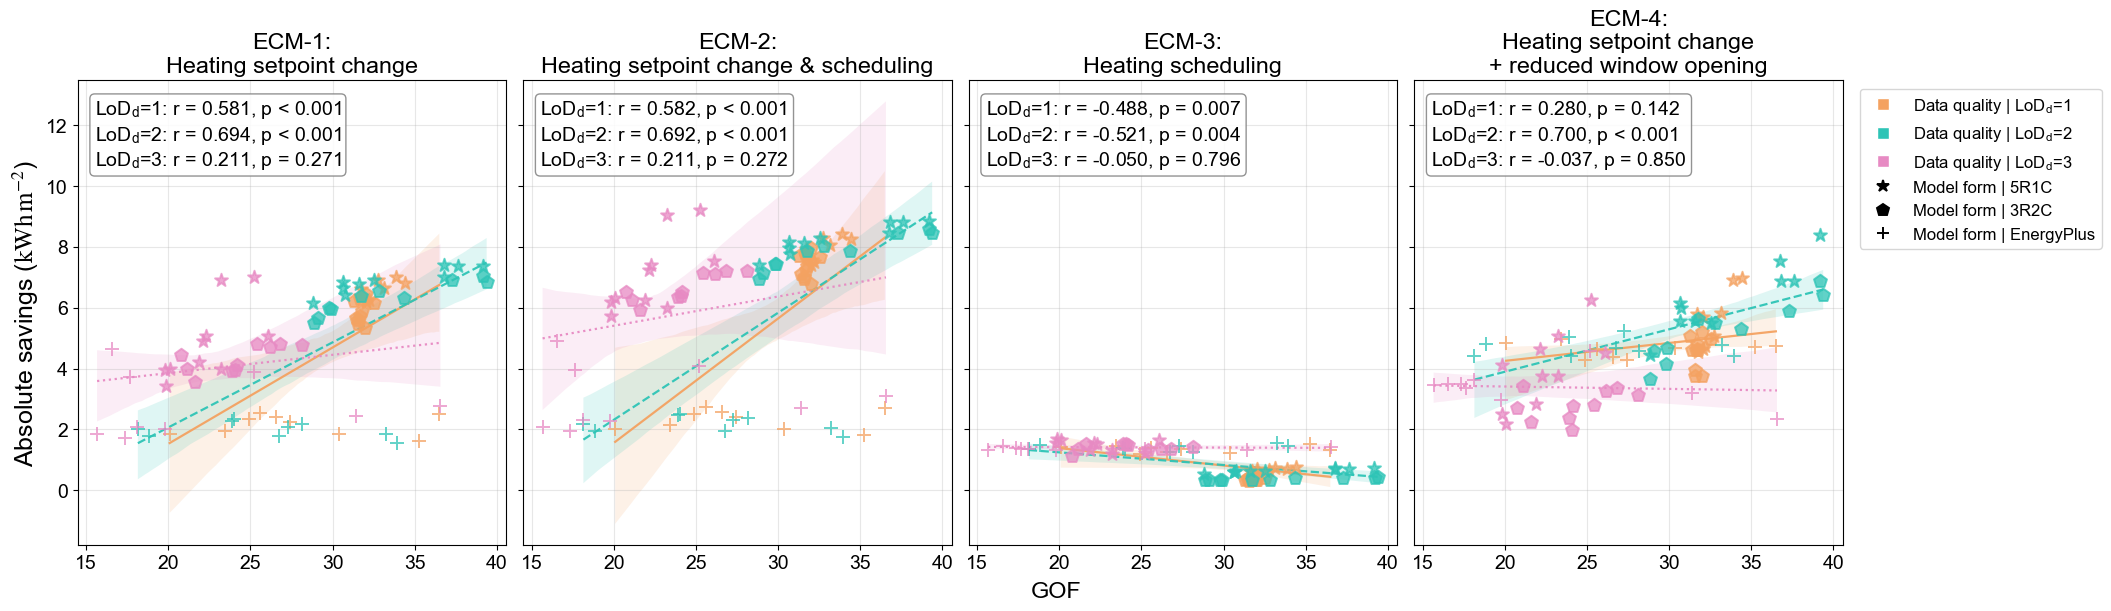

(<Figure size 2100x600 with 4 Axes>,
 array([<Axes: title={'center': 'ECM-1:\nHeating setpoint change'}, ylabel='Absolute savings ($\\mathrm{kWh\\,m^{-2}}$)'>,
        <Axes: title={'center': 'ECM-2:\nHeating setpoint change & scheduling'}>,
        <Axes: title={'center': 'ECM-3:\nHeating scheduling'}>,
        <Axes: title={'center': 'ECM-4:\nHeating setpoint change\n+ reduced window opening'}>],
       dtype=object))

In [107]:
plot_rq2_scatter_by_lod_ci(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
)

In [108]:
def plot_rq2_scatter_by_engine_ci(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
):
    engine_order = ["5R1C", "3R2C","EnergyPlus", ]
    quality_order = ["LoD-1", "LoD-2", "LoD-3"]
    ecm_order = ["O&M-1", "O&M-2", "O&M-3", "O&M-4"]

    metric_label_map = {
        "GOF": "GOF",
        "CVRMSE": "CVRMSE (%)",
        "NMBE": "NMBE (%)",
        "saving_abs": (
            r"Absolute savings "
            r"($\mathrm{kWh\,m^{-2}}$)"
        ),
        "saving_frac": "Relative savings (%)",
        "saving_pct": "Relative savings (%)",
    }

    x_label = metric_label_map.get(error_metric, error_metric)
    y_label = metric_label_map.get(saving_metric, saving_metric)

    quality_display_map = {
        "LoD-1": r"$\mathregular{LoD}_{\mathregular{d}}$=1",
        "LoD-2": r"$\mathregular{LoD}_{\mathregular{d}}$=2",
        "LoD-3": r"$\mathregular{LoD}_{\mathregular{d}}$=3",
    }

    ecm_label_map = {
        "O&M-1": "ECM-1:\nHeating setpoint change",
        "O&M-2": "ECM-2:\nHeating setpoint change & scheduling",
        "O&M-3": "ECM-3:\nHeating scheduling",
        "O&M-4": "ECM-4:\nHeating setpoint change\n+ reduced window opening",
    }

    engine_palette = {
        "EnergyPlus": "red",
        "5R1C": "blue",
        "3R2C": "green",
    }

    marker_map = {
        "LoD-1": "o",
        "LoD-2": "D",
        "LoD-3": "^",
    }

    df = rq2_df.copy()
    df = df[
        df["engine"].isin(engine_order)
        & df["data_quality"].isin(quality_order)
        & df["ecm_common"].isin(ecm_order)
    ].copy()

    fig, axes = plt.subplots(
        1,
        len(ecm_order),
        figsize=(21, 6),
        sharey=True,
        constrained_layout=True,
    )

    for i, (ax, ecm) in enumerate(zip(axes, ecm_order)):
        d = df[df["ecm_common"] == ecm].dropna(
            subset=[error_metric, saving_metric]
        )

        stat_lines = []

        # Engine-specific regression lines and confidence bands
        for engine in engine_order:
            d_engine = d[d["engine"] == engine].copy()

            if (
                len(d_engine) >= 3
                and d_engine[error_metric].nunique() > 1
                and d_engine[saving_metric].nunique() > 1
            ):
                sns.regplot(
                    data=d_engine,
                    x=error_metric,
                    y=saving_metric,
                    scatter=False,
                    ci=95,
                    color=engine_palette[engine],
                    line_kws={
                        "linewidth": 1.5,
                        "alpha": 0.85,
                    },
                    ax=ax,
                )

                r, p = pearsonr(
                    d_engine[error_metric],
                    d_engine[saving_metric],
                )

                stat_lines.append(
                    f"{engine}: r = {r:.3f}, {fmt_p(p)}"
                )
            else:
                stat_lines.append(
                    f"{engine}: r = NA, p = NA"
                )

        # Scatter points on top of regression bands
        sns.scatterplot(
            data=d,
            x=error_metric,
            y=saving_metric,
            hue="engine",
            hue_order=engine_order,
            palette=engine_palette,
            style="data_quality",
            style_order=quality_order,
            markers=marker_map,
            s=75,
            alpha=0.55,
            edgecolor="grey",
            linewidth=0.4,
            ax=ax,
            legend=False,
        )

        ax.text(
            0.04,
            0.96,
            "\n".join(stat_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "grey",
                "alpha": 0.85,
            },
        )

        ax.set_title(ecm_label_map.get(ecm, ecm))
        ax.set_xlabel("")

        if i == 0:
            ax.set_ylabel(y_label)
        else:
            ax.set_ylabel("")

        ax.grid(True, alpha=0.3)

    fig.supxlabel(x_label)
    # One merged legend: model form + data quality
    legend_handles = []
    legend_labels = []

    # Model form: coloured markers
    for engine in engine_order:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker="s",
                color="w",
                markerfacecolor=engine_palette[engine],
                markeredgecolor=None,
                markersize=8,
                linewidth=0,
            )
        )
        legend_labels.append(f"Model form | {engine}")

    # Data quality: black symbols
    for lod in quality_order:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                marker=marker_map[lod],
                color="black",
                markerfacecolor="black",
                markeredgecolor=None,
                markersize=8,
                markeredgewidth=1.4,
                linewidth=0,
            )
        )
        legend_labels.append(f"Data quality | {quality_display_map[lod]}")

    axes[-1].legend(
        legend_handles,
        legend_labels,
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=True,
    )

    plt.show()

    return fig, axes

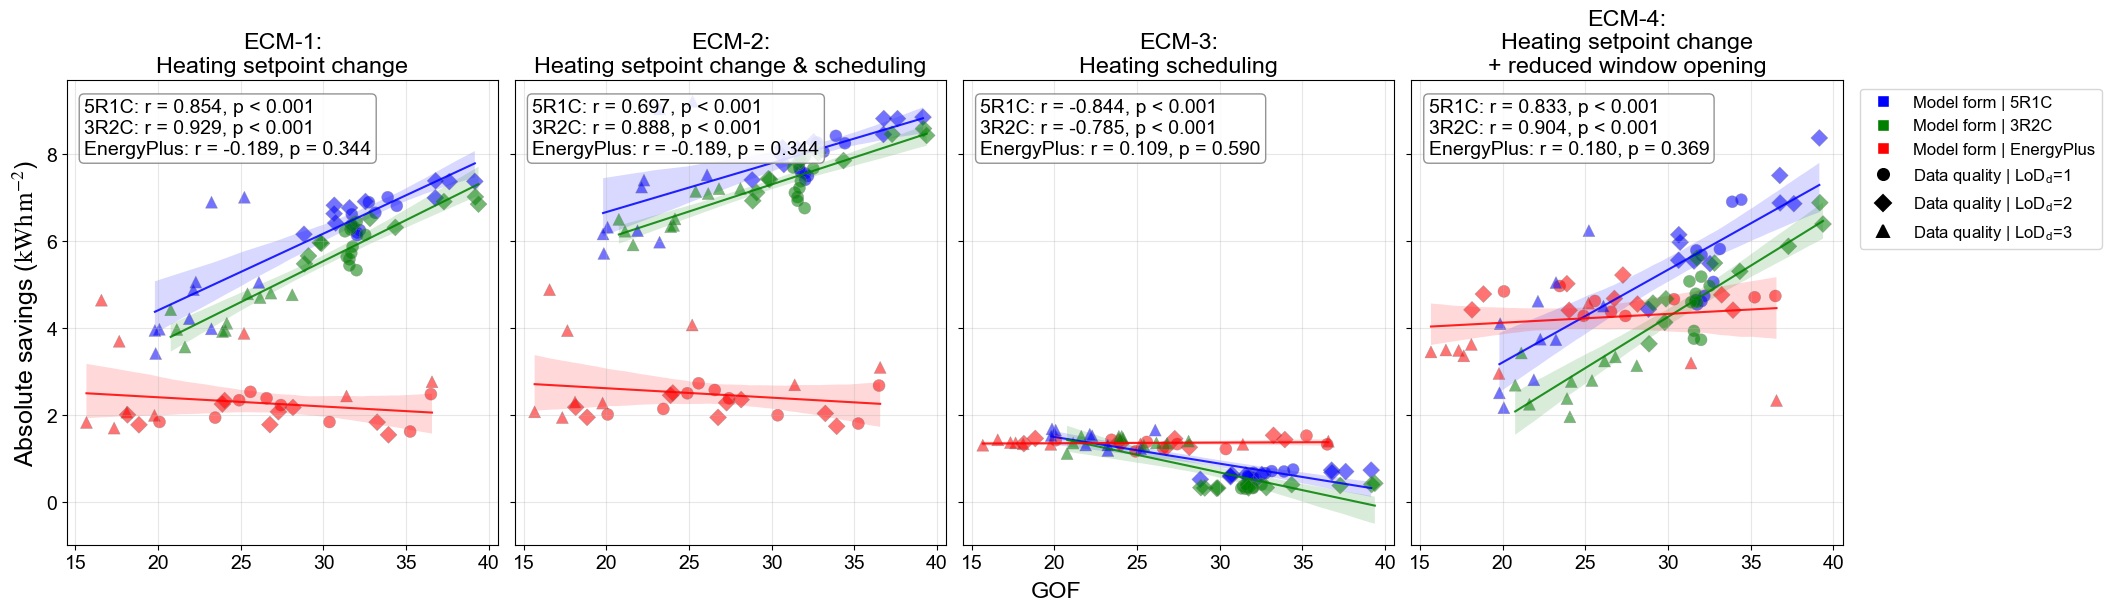

(<Figure size 2100x600 with 4 Axes>,
 array([<Axes: title={'center': 'ECM-1:\nHeating setpoint change'}, ylabel='Absolute savings ($\\mathrm{kWh\\,m^{-2}}$)'>,
        <Axes: title={'center': 'ECM-2:\nHeating setpoint change & scheduling'}>,
        <Axes: title={'center': 'ECM-3:\nHeating scheduling'}>,
        <Axes: title={'center': 'ECM-4:\nHeating setpoint change\n+ reduced window opening'}>],
       dtype=object))

In [109]:
plot_rq2_scatter_by_engine_ci(
    rq2_df,
    error_metric="GOF",
    saving_metric="saving_abs",
)